In [12]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import openpyxl
# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
import matplotlib.font_manager as fm

# 폰트 경로 설정
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'  # MacOS
# font_path = 'C:/Windows/Fonts/malgun.ttf'  # Windows

# 폰트 추가
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'AppleGothic'  # MacOS
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지



In [9]:
df = pd.read_excel('./data/21.11-24.6환자 CC_PI_치료계획.xlsx')
df['날짜'] = pd.to_datetime(df['날짜'])

In [10]:
d = df[['환자번호','날짜']]
d.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28108 entries, 0 to 28107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   환자번호    28108 non-null  object        
 1   날짜      28108 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 439.3+ KB


환자별 평균 방문 간격(일):
count    4199.000000
mean       40.343641
std        35.098317
min         0.000000
25%        23.679487
50%        36.000000
75%        47.242647
max       566.000000
Name: 방문간격, dtype: float64


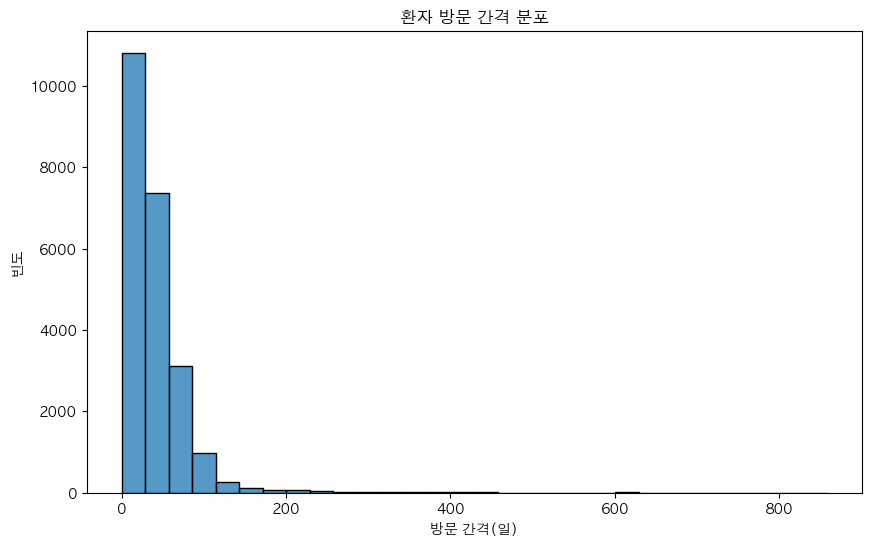

In [13]:
# 환자별 방문 날짜를 정렬
d_sorted = d.sort_values(['환자번호', '날짜'])

# 환자별 방문 간격 계산
d_sorted['방문간격'] = d_sorted.groupby('환자번호')['날짜'].diff().dt.days

# 환자별 평균 방문 간격 계산
avg_duration = d_sorted.groupby('환자번호')['방문간격'].mean()

print("환자별 평균 방문 간격(일):")
print(avg_duration.describe())

# 방문 간격 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=d_sorted['방문간격'].dropna(), bins=30)
plt.title('환자 방문 간격 분포')
plt.xlabel('방문 간격(일)')
plt.ylabel('빈도')
plt.show()


In [18]:
d_sorted.groupby('환자번호').agg({'환자번호':'count','방문간격': ['mean','median','std']})

환자번호       방문간격                   
        count       mean median         std
환자번호                                       
2111-04     4  97.333333   14.0  144.337567
2111-07     7  45.666667    7.0   62.647160
2111-08     6  39.400000   26.0   40.556134
2111-09     2   7.000000    7.0         NaN
2111-10    15  46.071429   38.0   29.029068
...       ...        ...    ...         ...
2405-86     1        NaN    NaN         NaN
2405-88     1        NaN    NaN         NaN
2405-89     1        NaN    NaN         NaN
2405-96     1        NaN    NaN         NaN
2405-99     1        NaN    NaN         NaN

[5132 rows x 4 columns]

In [20]:
d_sorted.query("환자번호=='2111-10'")

,환자번호,날짜,방문간격
17510,2111-10,2021-11-15,NaN
17511,2111-10,2021-11-22,7.0
17512,2111-10,2021-12-03,11.0
17513,2111-10,2021-12-17,14.0
17514,2111-10,2022-01-25,39.0
17515,2111-10,2022-03-03,37.0
17516,2111-10,2022-04-04,32.0
17517,2111-10,2022-05-09,35.0
17518,2111-10,2022-07-11,63.0
17519,2111-10,2022-08-22,42.0


In [27]:
result1 = d_sorted.groupby('환자번호').agg({
    '환자번호':'count',
    '방문간격': ['mean','median','std']
}).rename(columns={'count':'count'})

result1.columns = ['환자수', '방문간격_mean', '방문간격_median', '방문간격_std']
result1.reset_index(inplace=True)
result1.환자수.min(), result1.환자수.max()

(1, 75)

### 신규 -> 재방문 -> 충성고객 전환

### 

In [28]:
# 환자수를 10개의 구간으로 분류하고 그룹화
bins = pd.cut(result1.환자수, bins=10)
result1.groupby(bins).size()

# 교환권 사용 횟수 구간별 유저 분포 확인
result1['exchange_group'] = pd.cut(grp['exchange_cnt'], 
                              bins=[-float('inf'), 0, 1, 5, float('inf')],
                              labels=['0회', '1회', '2회 이상 5회 미만', '5회 이상'])

/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_75530/2675172027.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1.groupby(bins).size()


환자수
(0.926, 8.4]    4092
(8.4, 15.8]      812
(15.8, 23.2]     183
(23.2, 30.6]      25
(30.6, 38.0]      15
(38.0, 45.4]       3
(45.4, 52.8]       1
(52.8, 60.2]       0
(60.2, 67.6]       0
(67.6, 75.0]       1
dtype: int64